# Imports

In [1]:
%load_ext autoreload
%autoreload 2

import logging

import msml610_utils as ut

ut.config_notebook()

# Initialize logger.
logging.basicConfig(level=logging.INFO)
_LOG = logging.getLogger(__name__)

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
vim support installed: restart the notebook, if needed


Python 3.12.3
Linux 7d77d2247121 6.12.67-linuxkit #1 SMP Sun Jan 25 02:26:28 UTC 2026 aarch64 aarch64 aarch64 GNU/Linux


In [2]:
import helpers.hio as hio
import L09_05_02_kalman_filter_utils as time_ut

dst_dir = "figures"
hio.create_dir(dst_dir, incremental=True)
# cp msml610/tutorials/figures/*.png msml610/lectures_source/figures

# Cell 1: Sum and Product of Gaussians

In [3]:
x = time_ut.Gaussian(3.4, 10.1)
print(x)
print("x.mean=", x.mean)
print("x.var=", x.var)

N(mu=3.400, sigma^2=10.100)
x.mean= 3.4
x.var= 10.1


## Cell 1.1: Sum of Gaussians
- Given two Gaussians $X$ and $Y$
  $$X \sim Normal(\mu_1, \sigma_1^2)$$
  $$Y \sim Normal(\mu_2, \sigma_2^2)$$
- For correlated Gaussians with correlation coefficient $\rho$, the sum
  $Z = X + Y$ is a Gaussian $Normal(\mu, \sigma^2)$ with:
  $$\mu = \mu_1 + \mu_2$$
  $$\sigma^2 = \sigma_1^2 + \sigma_2^2 + 2\rho\sigma_1\sigma_2$$
- **Interpretation:**
  - The mean is the sum of the means (by linearity)
  - For independent Gaussians ($\rho = 0$), the variance is the sum of
    variances (uncertainty increases)
  - Positive correlation increases variance, negative correlation decreases it

In [4]:
# Sum two Gaussians.
x = time_ut.Gaussian(10, 0.2**2)
y = time_ut.Gaussian(15, 0.7**2)

z = time_ut.gaussian_sum(x, y)
print(z)

N(mu=25.000, sigma^2=0.530)


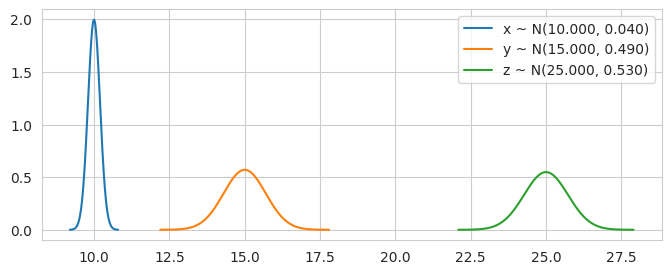

In [5]:
ax = time_ut.plot_gaussian(x, label="x")
time_ut.plot_gaussian(y, ax=ax, label="y")
time_ut.plot_gaussian(z, ax=ax, label="z");

**Goal**:
- Explore the sum of two Gaussians $X \sim N(\mu_1, \sigma_1^2)$ and
  $Y \sim N(\mu_2, \sigma_2^2)$ with correlation $\rho$
- Observe how mean and variance of $Z = X + Y$ change with parameters

**Plots**:
- Input Gaussians $X$ (blue) and $Y$ (yellow) as filled PDFs
- Analytical sum $Z$ (red line)
- Numerical sum via sampling (light coral histogram)

**Parameters**:
- `mu1` ($\mu_1$): mean of $X$
- `sigma1` ($\sigma_1$): standard deviation of $X$
- `mu2` ($\mu_2$): mean of $Y$
- `sigma2` ($\sigma_2$): standard deviation of $Y$
- `rho` ($\rho$): correlation coefficient between $X$ and $Y$

**Key observations**:
- The mean of $Z$ is always $\mu_1 + \mu_2$ regardless of correlation
- Positive $\rho$ increases variance; negative $\rho$ decreases it
- For independent Gaussians ($\rho = 0$), variance is simply
  $\sigma_1^2 + \sigma_2^2$

In [6]:
# Interactive exploration of sum of Gaussians with correlation.
time_ut.cell1_1_plot_gaussian_sum()

## Cell 1.2: Product of Gaussians
- Given two Gaussians $X$ and $Y$
  $$X \sim Normal(\mu_X, \sigma_X^2)$$
  $$Y \sim Normal(\mu_Y, \sigma_Y^2)$$
- The product $Z = X \cdot Y$ (PDF multiplication) is a Gaussian
  $Normal(\mu_Z, \sigma_Z^2)$ with:
  $$\mu_Z = \frac{\mu_X \sigma_Y^2 + \mu_Y \sigma_X^2}{\sigma_X^2 + \sigma_Y^2}$$
  $$\sigma_Z^2 = \frac{\sigma_X^2 \sigma_Y^2}{\sigma_X^2 + \sigma_Y^2}$$
- **Interpretation:**
  - Reduces variance by incorporating more information
  - If one Gaussian $X$ is narrower (more accurate), result leans towards $X$
  - If two Gaussians are similar (measures corroborate), result becomes more
    certain

**Gaussian products in terms of precision**

- The precision of a Gaussian is
  $$\tau = \frac{1}{\sigma^2}$$
- The precision of the product is the sum of the precisions
  $$\tau_Z = \tau_X + \tau_Y$$
  $$\sigma_Z^2 = \frac{1}{\frac{1}{\sigma_X^2} + \frac{1}{\sigma_Y^2}}$$
- The mean is the average of the means weighted by the precisions
  $$\mu_Z = \sigma_Z^2 (\frac{\mu_X}{\sigma_X^2} + \frac{\mu_Y}{\sigma_Y^2})$$

- The mean is averaged towards the more certain Gaussian
- The variance is smaller than both

In [7]:
# Product of two equal Gaussians.
x = time_ut.Gaussian(10, 1.0)

z = time_ut.gaussian_multiply(x, x)
print(z)

# The result is more certain than both.

N(mu=10.000, sigma^2=0.500)


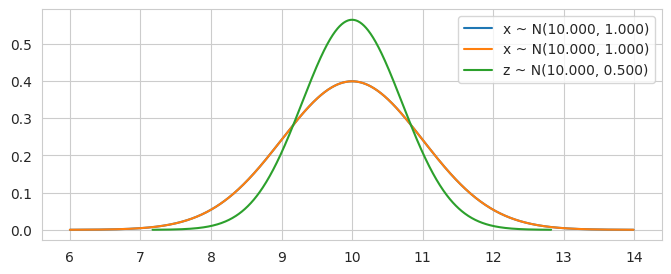

In [8]:
ax = time_ut.plot_gaussian(x, label="x")
time_ut.plot_gaussian(x, ax=ax, label="x")
time_ut.plot_gaussian(z, ax=ax, label="z");

N(mu=10.377, sigma^2=0.037)


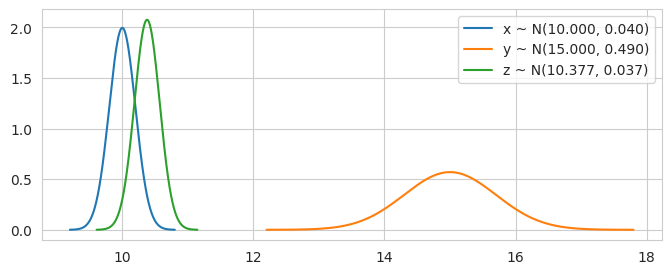

In [9]:
# Product of two different Gaussians.
x = time_ut.Gaussian(10, 0.2**2)
y = time_ut.Gaussian(15, 0.7**2)

z = time_ut.gaussian_multiply(x, y)
print(z)

ax = time_ut.plot_gaussian(x, label="x")
time_ut.plot_gaussian(y, ax=ax, label="y")
time_ut.plot_gaussian(z, ax=ax, label="z");

N(mu=9.950, sigma^2=0.500)


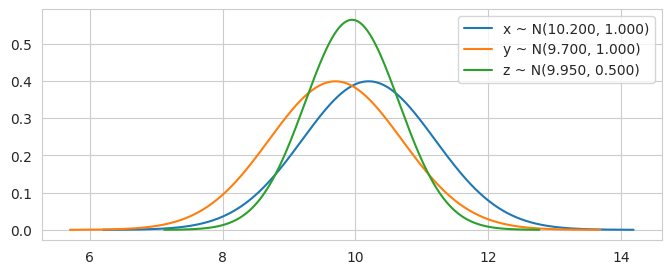

In [10]:
x = time_ut.Gaussian(10.2, 1)
y = time_ut.Gaussian(9.7, 1)

z = time_ut.gaussian_multiply(x, y)
print(z)

ax = time_ut.plot_gaussian(x, label="x")
time_ut.plot_gaussian(y, ax=ax, label="y")
time_ut.plot_gaussian(z, ax=ax, label="z");

**Goal**:
- Explore the product of two Gaussian PDFs $X \sim N(\mu_1, \sigma_1^2)$ and
  $Y \sim N(\mu_2, \sigma_2^2)$
- Observe how combining two beliefs (product) reduces uncertainty

**Plots**:
- Input Gaussians $X$ (blue) and $Y$ (yellow) as filled PDFs
- Analytical product $Z$ (red line)
- Numerical product via importance sampling (light coral histogram)

**Parameters**:
- `mu1` ($\mu_1$): mean of $X$
- `sigma1` ($\sigma_1$): standard deviation of $X$
- `mu2` ($\mu_2$): mean of $Y$
- `sigma2` ($\sigma_2$): standard deviation of $Y$

**Key observations**:
- The product pulls the mean toward the more certain (narrower) Gaussian
- The resulting variance is smaller than both input variances
- When inputs agree, the result is very sharp (high certainty)

In [11]:
# Interactive exploration of product of Gaussians.
time_ut.cell1_2_plot_gaussian_product()

# Cell 2: Tracking the Dog

- The intuition is the same as the discrete case

- There is a cycle of prediction and updates
    1) Predict: prior = x_est using system model
    2) Update: posterior = likelihood * prior

- Create prior (using current estimate and system model)
  - `prior = predict(x, process_model)`
- Create likelihood (using measurement)
  - `likelihood = gaussian(z, sensor_var)`
- Update belief using prior and likelihood
  - `x = update(prior, likelihood)`

- Sum adds uncertainty
- Multiplication reduces uncertainty

- Let's assume that the dog moves in the hallway, back and forth
  - It's not circular
- We have a sensor that measures the distance of the dog from one extreme

We can use Newton's equation of motion to compute the position of the dog,
based on current position and velocity

$$\overline{x}_k = x_{k-1} + v_k \Delta_t$$

- $x_{k-1}$ has uncertainty quantified by a Gaussian
- $v_k$ has also uncertainty quantified by a Gaussian

We can compute the sum of two Gaussians in terms of mean and uncertainty
- It makes sense since we know that uncertainty becomes larger

- The likelihood $z | x$ is the probability of measures given the current
  state



In [19]:
import numpy as np
np.random.seed(13)

# Variance in the dog's movement.
process_var = 1.0
# Variance in the sensor.
sensor_var = 2.0

# Dog's initial position.
x = time_ut.Gaussian(0.0, 20.0**2)
velocity = 1.0
# Time step in seconds.
dt = 1.0
# Displacement to add to x (representing how to model the movement of the dog).
process_model = time_ut.Gaussian(velocity * dt, process_var)

# Simulate dog and get measurements.
dog = time_ut.DogSimulation(
    x0=x.mean,
    velocity=process_model.mean,
    measurement_var=sensor_var,
    process_var=process_model.var)

# Simulate dog and collect measurements and actual positions.
n_steps = 10
sim_data = [dog.move_and_sense() for _ in range(n_steps)]
zs = [m for m, _ in sim_data]
actual_positions = [pos for _, pos in sim_data]
print(zs)

[1.3535959735108178, 1.8820653967131618, 4.341047429453569, 7.156332673205118, 6.938695089418526, 6.843912342028484, 9.846824080052299, 12.553482049375292, 16.2730841073834, 14.800411177015299]


In [20]:
# Perform Kalman filter on measurements.
kf_info = []
for z, actual_pos in zip(zs, actual_positions):
    prior = time_ut.predict(x, process_model)
    likelihood = time_ut.Gaussian(z, sensor_var)
    x = time_ut.update(prior, likelihood)
    kf_info.append(
        time_ut.KfInfo(prior=prior, measurement=z, actual_pos=actual_pos, posterior=x)
    )

print(time_ut.kf_info_to_df(kf_info))

   predict_x  predict_var          z  actual_pos   update_x  update_var
0   1.000000   401.000000   1.353596    0.287609   1.351841    1.990074
1   2.351841     2.990074   1.882065    1.243106   2.070349    1.198409
2   3.070349     2.198409   4.341047    3.588208   3.735724    1.047258
3   4.735724     2.047258   7.156333    5.938396   5.960160    1.011677
4   6.960160     2.011677   6.938695    8.417082   6.949397    1.002911
5   7.949397     2.002911   6.843912    8.628093   7.396253    1.000727
6   8.396253     2.000727   9.846824   10.190939   9.121670    1.000182
7  10.121670     2.000182  12.553482   12.104680  11.337631    1.000045
8  12.337631     2.000045  16.273084   13.231983  14.305380    1.000011
9  15.305380     2.000011  14.800411   14.838272  15.052895    1.000003


- The uncertainty after prediction is > than the uncertainty after update (as usual)
- The variance of the prior at time 0 is very large, but after we measure, the
    variance of the measurement "dominates" (i.
- The posterior values are always between the measurement and the prior
- After a few cycles the posterior variance is around 1, which is smaller than the sensor variance ~2
  - Using a model + measurements is better

In [ ]:
# Plot Kalman filter results.
time_ut.plot_kf_info(kf_info, show_actual_pos="scatter")

## Bad Initial Estimate

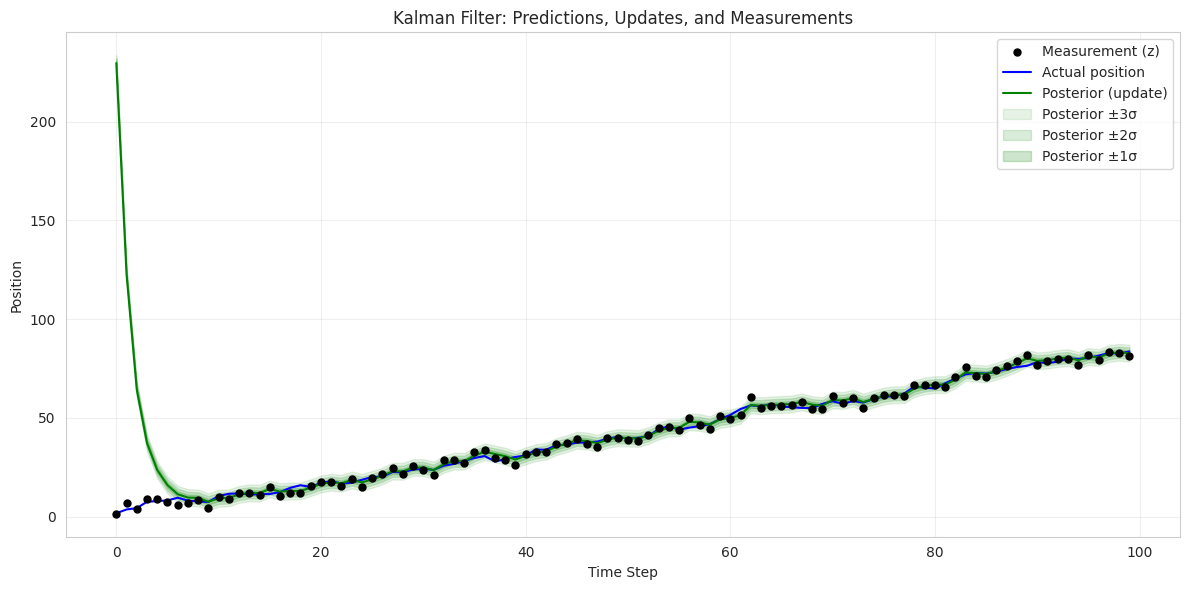

In [41]:
seed = 42
process_var = 2.0
sensor_var = 2.0 ** 2
# Belief about initial position.
initial_position = 400
initial_pos_var = 1.0
# Actual initial position.
actual_initial_pos = 0.0
n_steps = 100

kf_info = time_ut._run_dog_simulation(seed, process_var, sensor_var, initial_position, actual_initial_pos=actual_initial_pos, initial_pos_var=initial_pos_var, n_steps=n_steps)
time_ut.plot_kf_info(kf_info, show_prior="none", show_actual_pos="line", show_posterior="line")

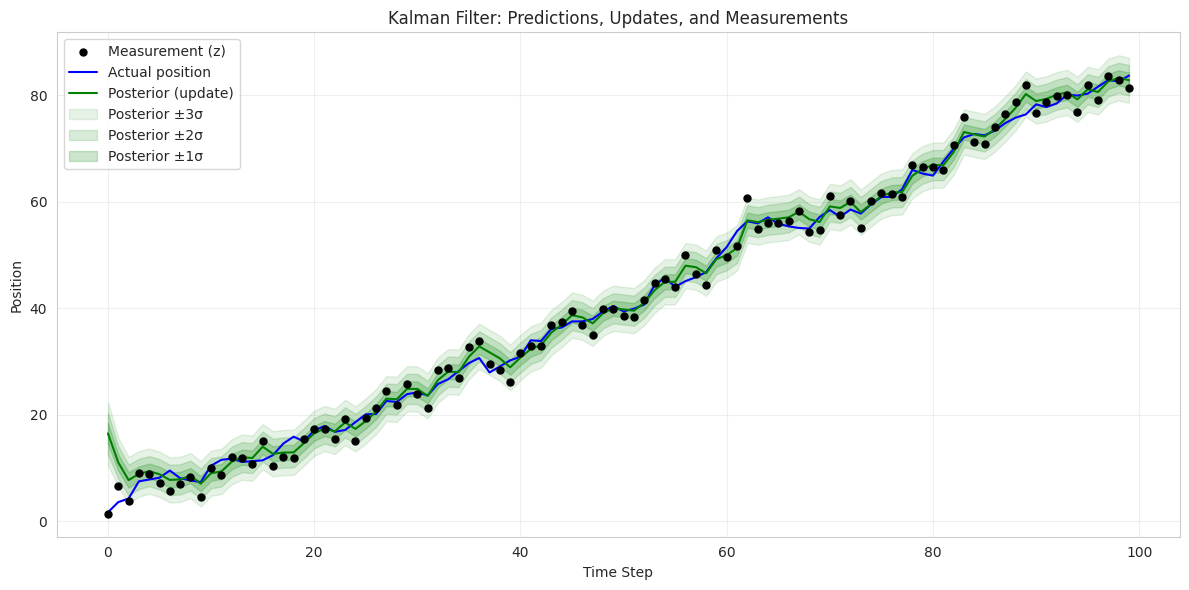

In [42]:
# Belief about initial position.
initial_position = 400
initial_pos_var = 100.0
# Actual initial position.
actual_initial_pos = 0.0

kf_info = time_ut._run_dog_simulation(seed, process_var, sensor_var, initial_position, actual_initial_pos=actual_initial_pos, initial_pos_var=initial_pos_var, n_steps=n_steps)
time_ut.plot_kf_info(kf_info, show_prior="none", show_actual_pos="line", show_posterior="line")

## Extreme amount of noise

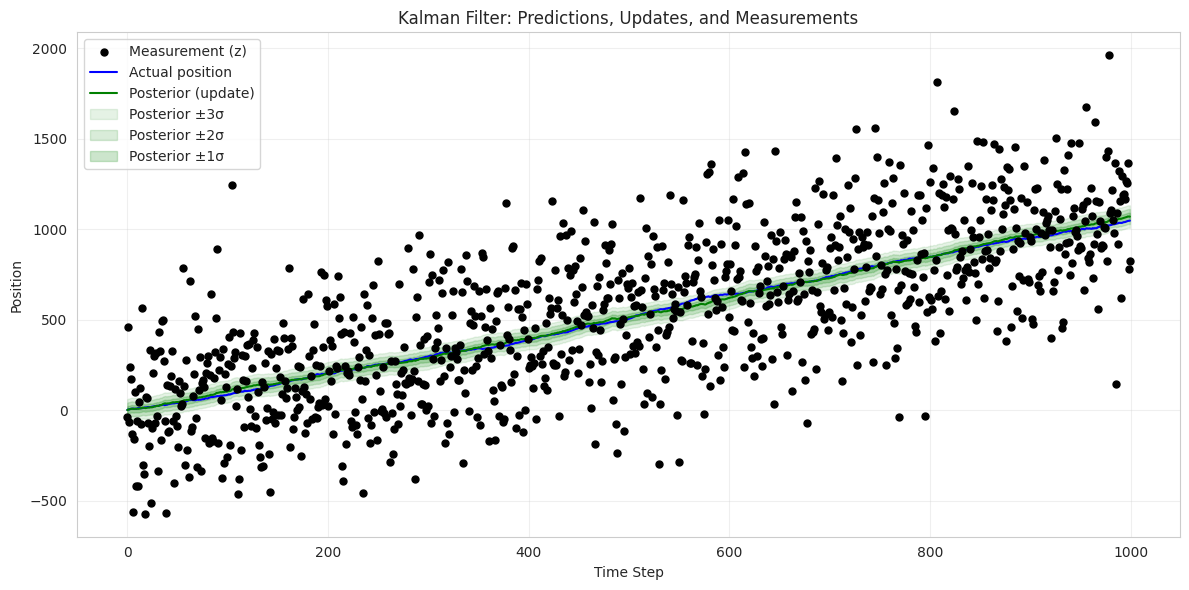

In [27]:
seed = 42
process_var = 2.0
sensor_var = 300.0 ** 2
initial_position = 0.0
n_steps = 1000

kf_info = time_ut._run_dog_simulation(seed, process_var, sensor_var, initial_position, n_steps=n_steps)
time_ut.plot_kf_info(kf_info, show_prior="none", show_actual_pos="line", show_posterior="line")

- Even with extreme amounts of noise we recover the position of the dog
  - This is because the process error is small (we can trust the model)

## Too much belief in the model

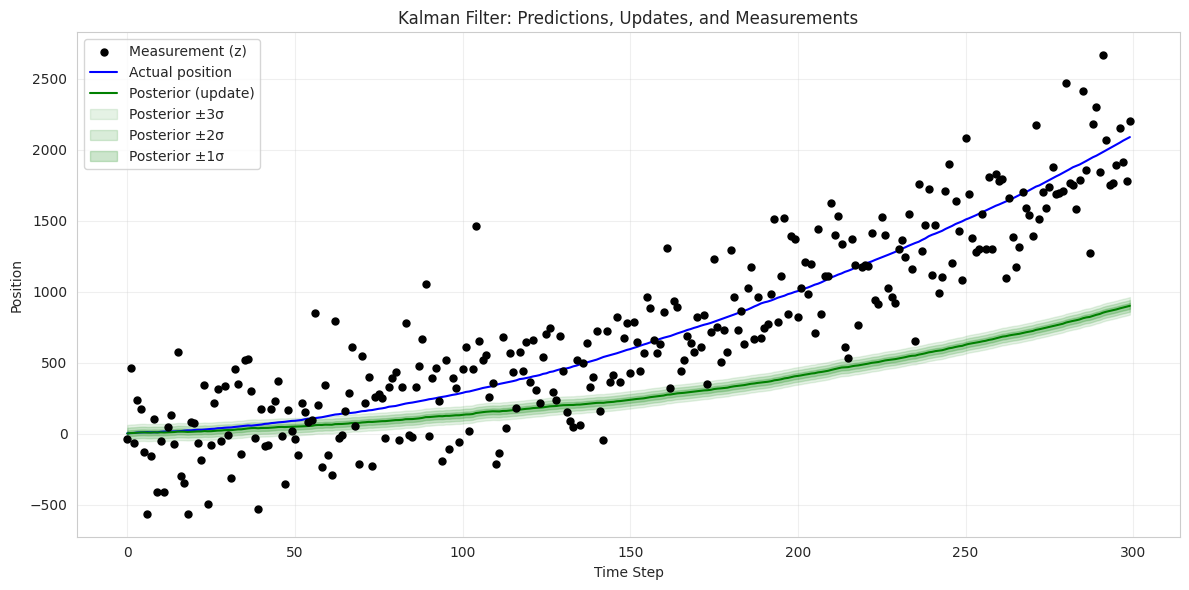

In [33]:
seed = 42
process_var = 2.0
sensor_var = 300.0 ** 2
acceleration = 0.04
initial_position = 0.0
n_steps = 300

kf_info = time_ut._run_dog_simulation(seed, process_var, sensor_var, initial_position, acceleration=acceleration, n_steps=n_steps)
time_ut.plot_kf_info(kf_info, show_prior="none", show_actual_pos="line", show_posterior="line")

- The filter is not able to follow the change of velocity of the dog

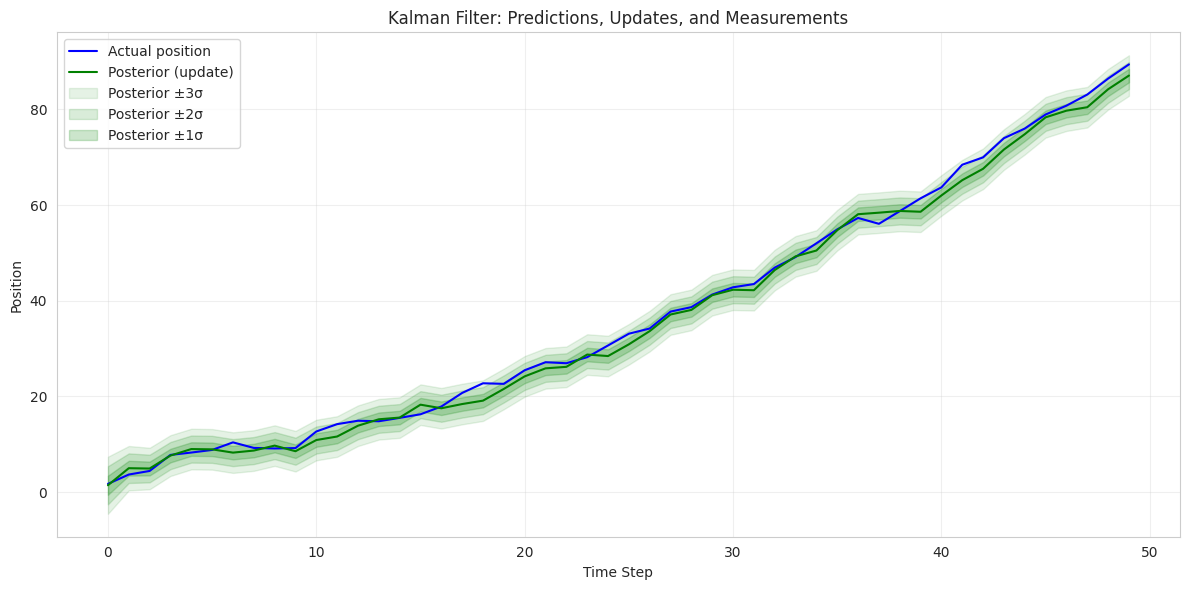

In [30]:
seed = 42
process_var = 2.0
sensor_var = 2.0 ** 2
acceleration = 0.04
initial_position = 0.0
n_steps = 50

kf_info = time_ut._run_dog_simulation(seed, process_var, sensor_var, initial_position, acceleration=acceleration, n_steps=n_steps)
time_ut.plot_kf_info(kf_info, show_prior="none", show_actual_pos="line", show_posterior="line", show_measurements="none")

**Goal**:
- Explore a Kalman filter tracking a dog moving in 1D with Gaussian noise
- Understand how the filter balances process model and sensor measurements

**Plots**:
- Prior (predict) as red up-triangles: prediction from motion model
- Measurement as black circles: noisy sensor readings
- Posterior (update) as green down-triangles: filtered estimate
- Posterior uncertainty as shaded green bands ($\pm 1, 2, 3 \sigma$)

**Parameters**:
- `process_var` ($\sigma_p^2$): variance in the dog's movement model
- `sensor_var` ($\sigma_s^2$): variance in the sensor measurements
- `initial_position` ($x_0$): belief about the dog's starting position
- `actual_initial_pos`: the dog's true starting position (can differ from
  belief to simulate a wrong initial estimate)
- `initial_pos_var`: uncertainty (variance) in the initial position belief;
  large values mean we are very uncertain about where the dog starts
- `acceleration`: dog's acceleration (m/s²); non-zero values make the dog
  speed up over time, testing the filter's ability to track
- `seed`: random seed for reproducibility

**Key observations**:
- With small `sensor_var`, measurements dominate and the filter trusts the sensor
- With small `process_var`, the motion model dominates and changes less
- After several steps, posterior variance stabilizes below both input variances

In [ ]:
# Interactive Dog simulation with adjustable parameters.
time_ut.cell2_interactive_dog_simulation()

- Is it better to have precise measurements (`sensor_var` << `process_var`) or vice versa?